# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ MPS optimization

Created: 15-07-2026

Objectives:
* Apply [mps optimization](../../time_reversal_symmetries/truncating_reduced_density_matrices/random_fdlu_noising_mps_optimization_sweep.ipynb) to [previously generated states](../../save_states/z2_f_x_z2_t_hamiltonians.ipynb) states.
* Check for MPS optimization scores, and extract $n_1$ and $\omega$ invariants.

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from time import time

In [9]:
from humanize import naturalsize

In [10]:
import pickle

In [11]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_triv_to_nontriv_n1_10_site_ed"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_nontriv_n1_to_nontriv_cocyle_10_site_ed"

# Import states

In [12]:
triv_groundstates = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [13]:
nontriv_groundstates = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [14]:
len(triv_groundstates), len(nontriv_groundstates),

(21, 21)

# Definitions

In [15]:
L = 10

In [16]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [17]:
parameters = np.linspace(0, 1, 201)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [18]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [19]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [20]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [21]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [22]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Defect operators

In [23]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [24]:
def normalize_A(A):
    # Ensure trace = 1
    trace = jnp.real((A & A.conj()).contract())
    A = A.multiply(trace**(-0.5), spread_over=A.num_tensors)

    # Equalize norms
    norms = [
        jnp.sqrt(jnp.real((a & a.conj()).contract()))
        for a in A.tensors
    ]
    geometric_mean_norms = jnp.pow(reduce(mul, norms), 1/(A.num_tensors))

    for a, norm in zip(A.tensors, norms):
        a.modify(data=a.data*geometric_mean_norms/norm)

    return A

In [25]:
alternative_vertical_index_dict = {
    'vLV': 'vLV_alt',
    'vRV': 'vRV_alt'
}

In [26]:
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [27]:
def get_rho_A_rho_overlap(rho, A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A.reindex(transpose_dict)
    t2 = A.conj()

    t = (rho & t1 & t2)

    return jnp.real(t.contract())

In [28]:
def loss_func(A, rho, rho_purity):

    out = jnp.real(
        rho_purity
        + get_rho_A_purity(A)
        -2*get_rho_A_rho_overlap(rho, A)
    )

    return out

In [29]:
def get_initial_rho_mps_representation(domains_dict):
    symmetry_sites = domains_dict['symmetry_sites']
    horizontal_bond_dimension = domains_dict['mps_horizontal_bond_dimension']
    vertical_bond_dimension = domains_dict['mps_vertical_bond_dimension']

    i = symmetry_sites[0]
    leftmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2,
            horizontal_bond_dimension
        )),
        inds=('vLV', f'k{i}', f'vH{i}')
    )

    interior_mps_tensors = [
        qtn.Tensor(
            data=random_uniform_complex((
                horizontal_bond_dimension,
                2,
                horizontal_bond_dimension
            )),
            inds=(f'vH{i-1}', f'k{i}', f'vH{i}')
        )
        for i in symmetry_sites[1:-1]
    ]

    i = symmetry_sites[-1]
    rightmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            horizontal_bond_dimension,
            2,
            vertical_bond_dimension
        )),
        inds=(f'vH{i-1}', f'k{i}', 'vRV')
    )

    mps_tensors = [
        leftmost_mps_tensor,
        *interior_mps_tensors,
        rightmost_mps_tensor
    ]
    
    A = qtn.TensorNetwork(mps_tensors)

    return A

In [30]:
def get_rho_mps_representation(qt_rho, rho_purity, domains_dict):
    A = get_initial_rho_mps_representation(domains_dict)

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    return A_opt, tnopt.losses, tnopt.loss_best

In [31]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [32]:
def get_rho_tilde(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
        *[
            t.reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho_tilde = ket_tn & bra_tn

    return rho_tilde

In [33]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [34]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [35]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [36]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [37]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

# Step through

In [38]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(2, 16)),
    'left_defect_sites': [2, 3, 4, 5],
    'right_defect_sites': [12, 13, 14, 15],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [39]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
	      0.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 1 1>  1023 
	      1.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 1 0>  1022 
	      2.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 0 1>  1021 
	      3.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 0 0>  1020 
	      4.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 1 1>  1019 
	      5.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 1 0>  1018 
	      6.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 0 1>  1017 
	      7.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 0 0>  1016 
	      8.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 1 1>  1015 
	      9.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 1 0>  1014 
	     10.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 0 1>  1013 
	     11.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 0 0>  1012 
	     12.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 0 1 1>  1011 
	     13.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1

In [40]:
psi = triv_groundstates[0]

In [41]:
inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

In [42]:
qt_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
    inds=inds
)

In [43]:
qt_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k2', 'k4', 'k6', 'k8', 'k10', 'k12', 'k14', 'k16', 'k18', 'k1', 'k3', 'k5', 'k7', 'k9', 'k11', 'k13', 'k15', 'k17', 'k19'), tags=oset([]))

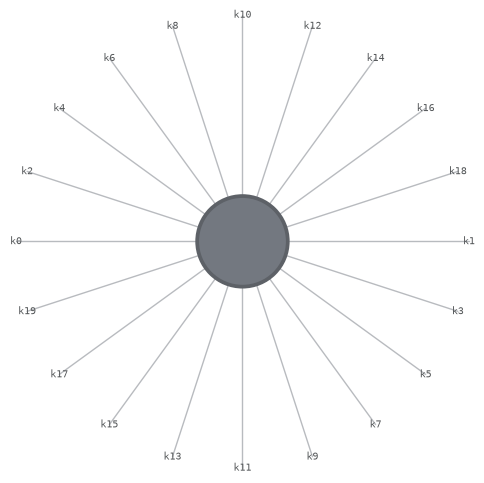

In [44]:
qt_psi.draw()

In [45]:
rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])

Looks ok.

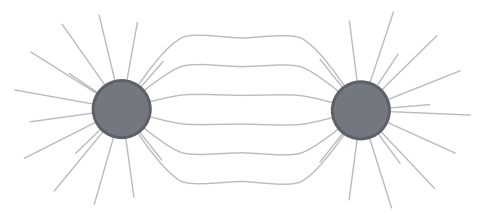

In [46]:
rho.draw()

In [47]:
rho

TensorNetwork(tensors=2, indices=34)

In [48]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [49]:
rho

TensorNetwork(tensors=2, indices=34)

In [50]:
rho_lr = (
    rho
    .reindex({f'k{i}': f'b{i}' for i in central_sites})
    .contract()
)

In [51]:
rho_lr

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k2', 'k4', 'k12', 'k14', 'k3', 'k5', 'k13', 'k15', 'b2', 'b4', 'b12', 'b14', 'b3', 'b5', 'b13', 'b15'), tags=oset([]))

In [52]:
left_defect_inds = (
    [f'k{i}' for i in domains_dict['left_defect_sites']]
    + [f'b{i}' for i in domains_dict['left_defect_sites']]
)

In [53]:
split_rho_lr = qtn.tensor_core.tensor_split(
    rho_lr,
    left_inds=left_defect_inds,
    absorb=None,
    bond_ind='vH'
)

In [54]:
split_rho_lr.tensors[1].data

array([1.])

In [55]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [56]:
rho_purity

1.0000000000000004

In [57]:
t1 = time()
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
t2 = time()

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [58]:
t2-t1

18.551187992095947

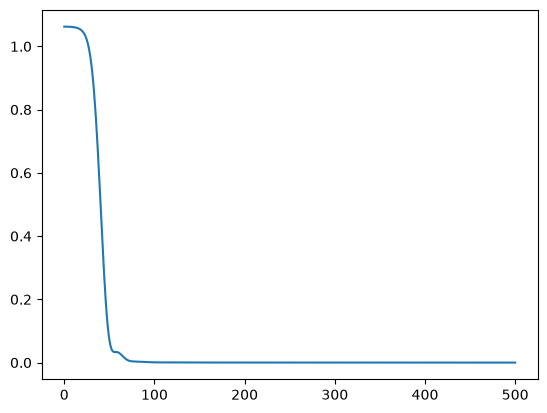

In [59]:
plt.plot(opt_out[1])

In [60]:
opt_out[1][-1]

2.09808349609375e-05

In [61]:
defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

In [62]:
defect_opt_out[0][:10]

array([9.8080546e-01, 4.8118045e-07, 4.3988186e-07, 4.1380883e-07,
       4.0674055e-07, 3.6899425e-07, 3.4228941e-07, 3.2407175e-07,
       2.9050844e-07, 2.7790830e-07], dtype=float32)

In [63]:
defect_opt_out[1]

Tensor(shape=(16, 16), inds=('kl', 'bl'), tags=oset([]))

In [64]:
defect_opt_out[3],defect_opt_out[4]

(np.complex128(0.9999981454698602+0j), np.complex128(0.9999859478976117+0j))

In [65]:
defect_opt_out[4]

np.complex128(0.9999859478976117+0j)

# Sweep

In [66]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(2, 16)),
    'left_defect_sites': [2, 3, 4, 5],
    'right_defect_sites': [12, 13, 14, 15],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [67]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [68]:
inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

In [69]:
triv_defect_results = list()
triv_opt_results = list()

for psi in tqdm(triv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])
    rho_purity = get_purity_from_quimb_rdm(rho)
    opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
    defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

    triv_opt_results.append(opt_out)
    triv_defect_results.append(defect_opt_out)

100%|███████████████████████████████████████████████████████████████████████████| 21/21 [06:25<00:00, 18.38s/it]


In [70]:
nontriv_defect_results = list()
nontriv_opt_results = list()

for psi in tqdm(nontriv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])
    rho_purity = get_purity_from_quimb_rdm(rho)
    opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
    defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

    nontriv_opt_results.append(opt_out)
    nontriv_defect_results.append(defect_opt_out)

100%|███████████████████████████████████████████████████████████████████████████| 21/21 [06:44<00:00, 19.26s/it]


## Analyze results
### Trivial

In [89]:
mps_scores = [l[1][-1] for l in triv_opt_results]

In [91]:
mps_scores

[2.849102020263672e-05,
 0.0005006790161132812,
 1.2636184692382812e-05,
 0.0035294294357299805,
 0.005872488021850586,
 0.008291006088256836,
 0.014073491096496582,
 0.007933855056762695,
 0.004655361175537109,
 0.003741621971130371,
 0.06674957275390625,
 0.0024213790893554688,
 0.004632711410522461,
 0.0016057491302490234,
 0.0004763603210449219,
 0.00018161535263061523,
 0.00011181831359863281,
 0.00010055303573608398,
 4.7773122787475586e-05,
 3.916025161743164e-05,
 1.940131187438965e-05]

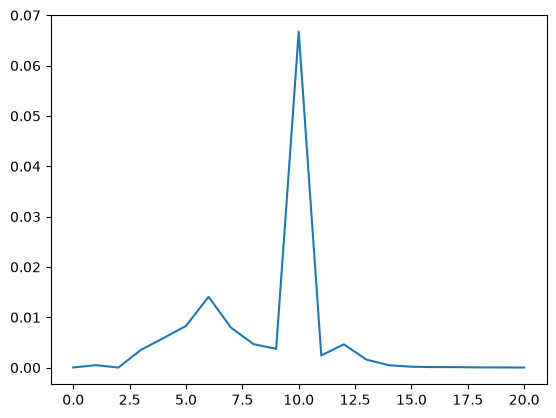

In [90]:
plt.plot(mps_scores)

In [71]:
overlaps = [l[-1] for l in triv_defect_results]

In [72]:
overlaps

[np.float32(0.9933665),
 np.float32(0.9768132),
 np.float32(0.9960799),
 np.float32(0.9498359),
 np.float32(0.93160284),
 np.float32(0.9485996),
 np.float32(0.9790206),
 np.float32(0.9358704),
 np.float32(0.9360143),
 np.float32(0.76334244),
 np.float32(0.16734287),
 np.float32(0.71977496),
 np.float32(0.9355138),
 np.float32(0.97644943),
 np.float32(0.987761),
 np.float32(0.99122435),
 np.float32(0.99229556),
 np.float32(0.9906616),
 np.float32(0.99384654),
 np.float32(0.9955973),
 np.float32(0.9957548)]

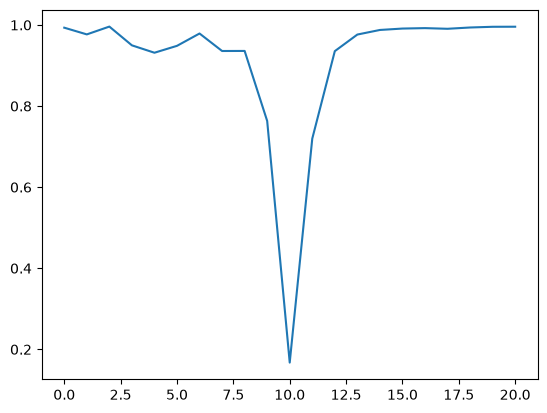

In [73]:
plt.plot(overlaps)

In [74]:
n1_indices = np.array([
    [l[3], l[4]]
    for l in triv_defect_results
])

In [75]:
np.round(n1_indices, 3)

array([[ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 1.   +0.j,  1.   +0.j],
       [ 0.998+0.j,  0.999-0.j],
       [ 0.996-0.j,  0.997-0.j],
       [ 0.994+0.j,  0.997+0.j],
       [ 0.991-0.j,  0.995-0.j],
       [ 0.994+0.j,  0.993+0.j],
       [ 0.993+0.j,  0.99 -0.j],
       [ 0.982+0.j,  0.984+0.j],
       [ 0.097+0.j,  0.391+0.j],
       [-0.9  -0.j, -0.911+0.j],
       [-0.797+0.j,  0.48 +0.j],
       [-0.937+0.j,  0.873+0.j],
       [-0.488-0.j,  0.751+0.j],
       [-0.999+0.j, -0.485+0.j],
       [-0.997-0.j, -0.422+0.j],
       [-0.71 +0.j,  0.758+0.j],
       [-0.997-0.j, -0.121-0.j],
       [-0.929-0.j, -0.868+0.j],
       [-0.989+0.j, -0.948-0.j]])

In [76]:
cocyle_indices = np.array([
    [l[5], l[6]]
    for l in triv_defect_results
])

In [77]:
cocyle_indices

array([[ 0.9999999 +1.24293464e-10j,  1.00000007-5.01075137e-09j],
       [ 0.9999999 -5.16053034e-11j,  1.00000035-1.90298466e-08j],
       [ 1.00000016-4.51829602e-10j,  0.99999963+1.52385343e-09j],
       [ 0.99999983+1.25808736e-08j,  0.99999979-1.13322385e-09j],
       [ 1.00000025+8.90330309e-09j,  0.9999999 +4.32894687e-09j],
       [ 1.00000019+1.51152409e-08j,  1.00000007-1.78638754e-09j],
       [ 1.0000003 -2.48800515e-08j,  1.00000013-2.14490544e-08j],
       [ 1.00000003+6.70253014e-09j,  1.00000008+6.86942969e-09j],
       [ 1.00000007+2.55191951e-09j,  1.00000041-7.23191124e-09j],
       [ 1.00000013-2.99407904e-08j,  0.99999996-3.65336978e-08j],
       [ 0.12023638-7.03126789e-02j,  0.35987591+7.23341195e-02j],
       [-1.        -4.03240283e-08j, -1.00000001-2.02065506e-08j],
       [-1.00000004-3.88581575e-08j, -1.00000002-1.12565692e-08j],
       [-0.99999997-5.09960926e-09j, -1.00000001+1.62636887e-08j],
       [-1.00000001-1.16071953e-08j, -0.99999998+2.97879296e-0

In [78]:
np.round(cocyle_indices, 3)

array([[ 1.  +0.j   ,  1.  -0.j   ],
       [ 1.  -0.j   ,  1.  -0.j   ],
       [ 1.  -0.j   ,  1.  +0.j   ],
       [ 1.  +0.j   ,  1.  -0.j   ],
       [ 1.  +0.j   ,  1.  +0.j   ],
       [ 1.  +0.j   ,  1.  -0.j   ],
       [ 1.  -0.j   ,  1.  -0.j   ],
       [ 1.  +0.j   ,  1.  +0.j   ],
       [ 1.  +0.j   ,  1.  -0.j   ],
       [ 1.  -0.j   ,  1.  -0.j   ],
       [ 0.12-0.07j ,  0.36+0.072j],
       [-1.  -0.j   , -1.  -0.j   ],
       [-1.  -0.j   , -1.  -0.j   ],
       [-1.  -0.j   , -1.  +0.j   ],
       [-1.  -0.j   , -1.  +0.j   ],
       [-1.  -0.j   , -1.  -0.j   ],
       [-1.  +0.j   , -1.  -0.j   ],
       [-1.  -0.j   , -1.  +0.j   ],
       [-1.  -0.j   , -1.  -0.j   ],
       [-1.  -0.j   , -1.  +0.j   ],
       [-1.  -0.j   , -1.  +0.j   ]])

### Nontrivial

In [95]:
mps_scores = [l[1][-1] for l in nontriv_opt_results]

In [96]:
mps_scores

[2.378225326538086e-05,
 7.149577140808105e-05,
 6.684660911560059e-05,
 8.627772331237793e-05,
 0.00021782517433166504,
 0.00047791004180908203,
 0.0009510517120361328,
 0.001820594072341919,
 0.0036246776580810547,
 0.006327539682388306,
 0.011266916990280151,
 0.006344258785247803,
 0.0035899877548217773,
 0.0019648373126983643,
 0.0009697973728179932,
 0.00035685300827026367,
 0.00021666288375854492,
 0.00010070204734802246,
 8.392333984375e-05,
 6.854534149169922e-07,
 1.3053417205810547e-05]

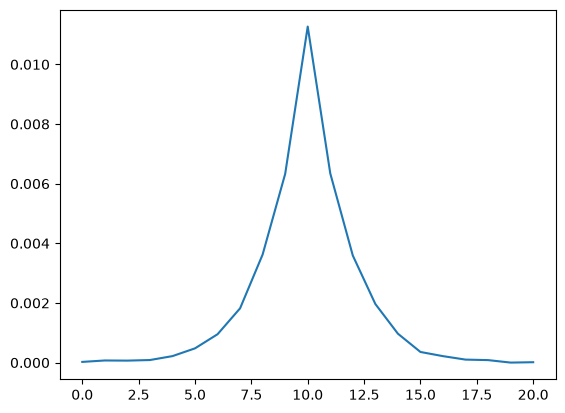

In [97]:
plt.plot(mps_scores)

In [83]:
n1_indices = np.array([
    [l[3], l[4]]
    for l in nontriv_defect_results
])

In [84]:
np.round(n1_indices, 3)

array([[-0.905+0.j,  0.124-0.j],
       [-0.963+0.j, -0.679+0.j],
       [-0.961-0.j,  0.202+0.j],
       [-0.995+0.j, -0.49 +0.j],
       [-0.996+0.j, -0.712+0.j],
       [-0.953+0.j, -0.872-0.j],
       [-0.983+0.j, -0.304+0.j],
       [-0.978-0.j, -0.146-0.j],
       [-0.997+0.j, -0.584-0.j],
       [-0.943+0.j, -0.983-0.j],
       [-0.971+0.j, -0.528-0.j],
       [-0.756+0.j, -0.739-0.j],
       [ 0.09 +0.j, -0.809+0.j],
       [-0.899+0.j, -0.884+0.j],
       [-0.995+0.j, -0.696+0.j],
       [-0.985+0.j, -0.995+0.j],
       [-0.999+0.j, -0.951-0.j],
       [-0.52 -0.j, -0.42 -0.j],
       [-0.982-0.j,  0.755-0.j],
       [-0.981-0.j, -0.992+0.j],
       [-0.311+0.j,  0.36 +0.j]])

In [87]:
cocyle_indices = np.array([
    [l[5], l[6]]
    for l in nontriv_defect_results
])

In [88]:
cocyle_indices

array([[-1.        -1.82784676e-10j, -0.99999998-1.40823020e-10j],
       [-1.        +9.46685452e-09j, -1.        -1.30008259e-08j],
       [-1.00000005+1.28146403e-08j, -1.        +2.82962211e-08j],
       [-1.00000002-2.13217867e-08j, -0.99999997+7.70010265e-09j],
       [-1.00000002+6.49380549e-10j, -1.00000005-1.25951816e-08j],
       [-1.00000001+6.34820185e-09j, -1.00000003+5.56663599e-07j],
       [-1.00000001+2.55353483e-09j, -1.00000002-8.34760328e-09j],
       [-1.00000002+2.06513107e-08j, -0.99999999+5.99087502e-09j],
       [-1.        +5.73947534e-09j, -1.        -1.38048035e-08j],
       [-1.        -1.37700458e-07j, -0.99999999+8.97106361e-09j],
       [-1.00000002-6.78971851e-09j, -0.99999997+8.28190960e-10j],
       [ 1.        +5.76110247e-08j,  0.99999997+2.49125229e-08j],
       [ 1.        +8.11949935e-09j,  0.99999998-1.27336099e-08j],
       [ 1.00000005-1.68954377e-08j,  1.00000003-1.26964688e-08j],
       [ 1.00000006-2.81471462e-08j,  0.99999998-4.23831081e-0

In [81]:
overlaps = [l[-1] for l in nontriv_defect_results]

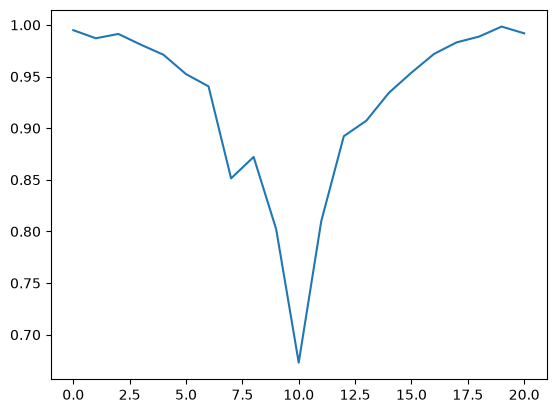

In [82]:
plt.plot(overlaps)